# Fase 4 (parte B) — CNN desde cero
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
CNN entrenada **desde cero** (sin transfer learning): 3 bloques
Conv→BatchNorm→MaxPool + GlobalAveragePooling + Dense + Dropout. Con data
augmentation, `class_weight` y callbacks (`EarlyStopping`, `ReduceLROnPlateau`).

In [1]:
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.data.paths import load_image_rgb
tf.random.set_seed(SEED); np.random.seed(SEED)
print("TF", tf.__version__, "| img", CNN_IMG_SIZE)

I0000 00:00:1780723493.393144  380440 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780723496.049749  380440 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF 2.21.0 | img (96, 96)


## 1. Cargar imágenes en memoria

In [2]:
def load_split(split, size=CNN_IMG_SIZE):
    m = load_manifest(split); X = np.zeros((len(m), *size, 3), np.float32); keep = np.ones(len(m), bool)
    for i, p in enumerate(m['abs_path']):
        img = load_image_rgb(p)
        if img is None: keep[i] = False; continue
        X[i] = cv2.resize(img, size).astype(np.float32) / 255.0
    return X[keep], m['quality_idx'].values[keep]
Xtr, ytr = load_split('train'); Xva, yva = load_split('val'); Xte, yte = load_split('test')
print("train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)

train (6570, 96, 96, 3) | val (1061, 96, 96, 3) | test (1082, 96, 96, 3)


## 2. Arquitectura

In [3]:
data_aug = models.Sequential([
    layers.RandomFlip("horizontal"), layers.RandomRotation(0.08),
    layers.RandomZoom(0.10), layers.RandomBrightness(0.10, value_range=(0,1)),
], name="augmentation")
def build_cnn():
    m = models.Sequential([
        layers.Input((*CNN_IMG_SIZE, 3)), data_aug,
        layers.Conv2D(32,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(), layers.Dense(128,activation='relu'), layers.Dropout(0.5),
        layers.Dense(len(QUALITY_CLASSES), activation='softmax'),
    ], name="FruitCNN")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
cnn = build_cnn(); cnn.summary()

E0000 00:00:1780723527.210917  380440 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

## 3. Entrenamiento

In [4]:
cw = compute_class_weight('balanced', classes=np.unique(ytr), y=ytr)
class_weight = dict(enumerate(cw))
print("class_weight:", {QUALITY_CLASSES[k]: round(v,2) for k,v in class_weight.items()})
cbs = [callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
       callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)]
history = cnn.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=40, batch_size=32,
                  class_weight=class_weight, callbacks=cbs, verbose=2)

class_weight: {'Premium': np.float64(1.2), 'Estándar': np.float64(0.98), 'Descarte': np.float64(0.87)}


Epoch 1/40


206/206 - 65s - 316ms/step - accuracy: 0.6050 - loss: 0.8744 - val_accuracy: 0.3402 - val_loss: 1.6020 - learning_rate: 0.0010


Epoch 2/40


206/206 - 66s - 318ms/step - accuracy: 0.6968 - loss: 0.7133 - val_accuracy: 0.7182 - val_loss: 0.7085 - learning_rate: 0.0010


...

206/206 - 71s - 345ms/step - accuracy: 0.9239 - loss: 0.2107 - val_accuracy: 0.9114 - val_loss: 0.2534 - learning_rate: 1.2500e-04


Epoch 21/40


206/206 - 71s - 342ms/step - accuracy: 0.9233 - loss: 0.2089 - val_accuracy: 0.9105 - val_loss: 0.2542 - learning_rate: 1.2500e-04


Epoch 22/40


206/206 - 71s - 343ms/step - accuracy: 0.9222 - loss: 0.2082 - val_accuracy: 0.9284 - val_loss: 0.2069 - learning_rate: 1.2500e-04


## 4. Curvas de aprendizaje

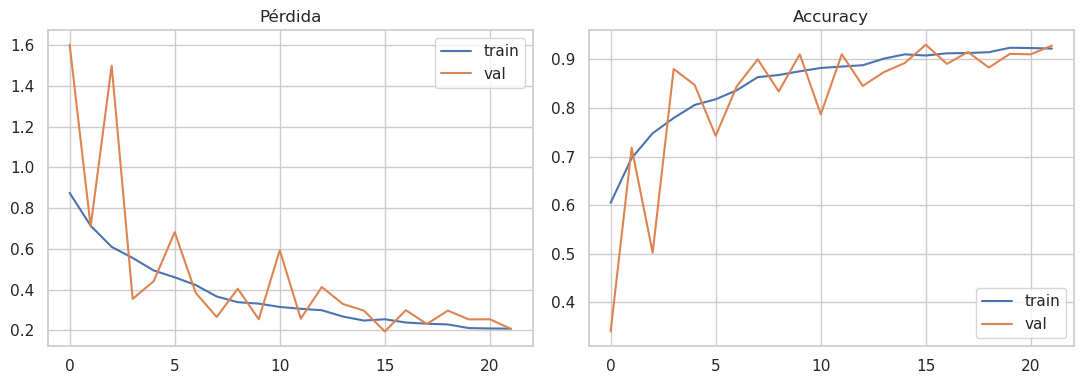

In [5]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val'); ax[0].set_title('Pérdida'); ax[0].legend()
ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val'); ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase4_cnn_curvas.pdf", bbox_inches="tight"); plt.show()

## 5. Evaluación en test

CNN -> accuracy=0.921 | f1_macro=0.922

              precision    recall  f1-score   support

     Premium      0.906     0.961     0.933       363
    Estándar      0.939     0.933     0.936       344
    Descarte      0.921     0.872     0.896       375

    accuracy                          0.921      1082
   macro avg      0.922     0.922     0.922      1082
weighted avg      0.922     0.921     0.921      1082



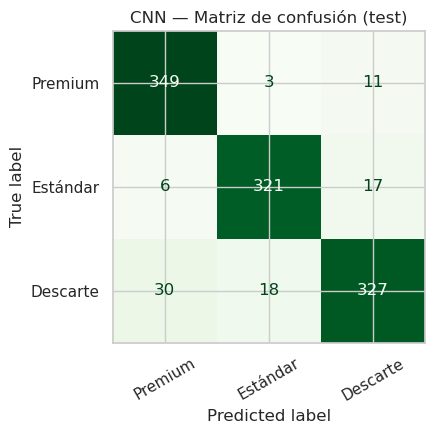

In [6]:
pred = cnn.predict(Xte, verbose=0).argmax(1)
acc = accuracy_score(yte, pred); f1 = f1_score(yte, pred, average='macro')
print(f"CNN -> accuracy={acc:.3f} | f1_macro={f1:.3f}\n")
print(classification_report(yte, pred, target_names=QUALITY_CLASSES, digits=3))
fig, axx = plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=QUALITY_CLASSES).plot(ax=axx, cmap='Greens', colorbar=False)
axx.set_title('CNN — Matriz de confusión (test)'); axx.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase4_cnn_confusion.pdf", bbox_inches="tight"); plt.show()

## 6. Guardado

In [7]:
cnn.save(MODELS_DIR / "cnn_quality.keras")
pd.DataFrame({'modelo':['CNN'],'accuracy':[acc],'f1_macro':[f1]}).to_csv(MODELS_DIR / "cnn_metrics.csv", index=False)
print("Modelo guardado en models/saved/cnn_quality.keras")

Modelo guardado en models/saved/cnn_quality.keras


➡️ **Siguiente:** Fase 5 — Evaluación comparativa.